ZIP file extracted successfully!
Total Images Loaded: 506
Classes Found: ['no' 'yes']
Training Images: 404
Testing Images: 102


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 645ms/step - accuracy: 0.6436 - loss: 0.6402 - val_accuracy: 0.7353 - val_loss: 0.5306
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 564ms/step - accuracy: 0.7649 - loss: 0.5083 - val_accuracy: 0.8137 - val_loss: 0.4670
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 563ms/step - accuracy: 0.8193 - loss: 0.4573 - val_accuracy: 0.8333 - val_loss: 0.4173
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 562ms/step - accuracy: 0.8292 - loss: 0.3742 - val_accuracy: 0.8235 - val_loss: 0.3673
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 551ms/step - accuracy: 0.8713 - loss: 0.2928 - val_accuracy: 0.8922 - val_loss: 0.3014
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 559ms/step - accuracy: 0.9183 - loss: 0.2200 - val_accuracy: 0.9314 - val_loss: 0.2085
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 556ms/step - accuracy: 0.9208 - loss: 0.1697 - val_accuracy: 0.9608 - val_loss: 0.1626
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 596ms/step - accuracy: 0.9653 - loss: 0.1007 - val_accur

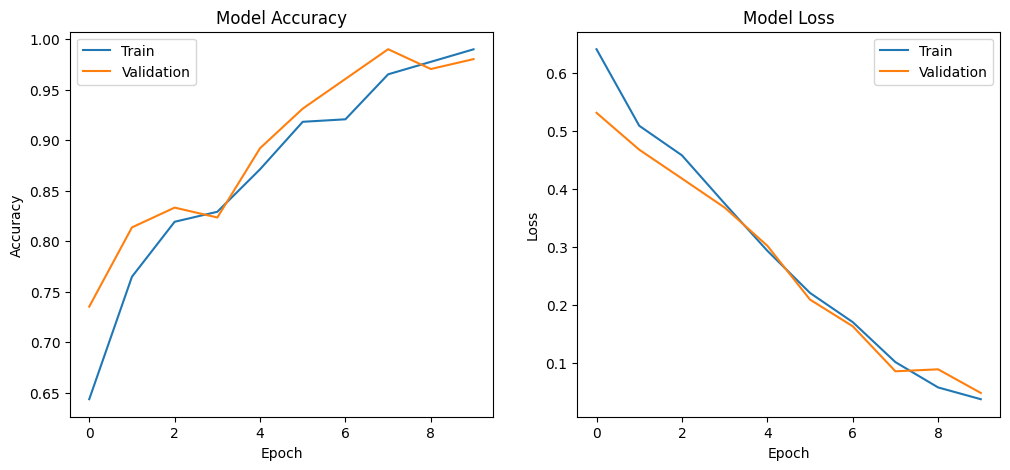

In [10]:
# ==========================
# Import Libraries
# ==========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# ==========================
# Step 1: Extract ZIP File
# ==========================
zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")

# ==========================
# Step 2: Load Images
# ==========================
images = []
labels = []

img_size = 128

for root, dirs, files_list in os.walk(extract_path):

    for file in files_list:

        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):

            img_path = os.path.join(root, file)

            img = cv2.imread(img_path)

            if img is not None:

                # Resize image
                img = cv2.resize(img, (img_size, img_size))

                # Convert BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                images.append(img)

                # Folder name becomes label
                label = os.path.basename(root)
                labels.append(label)

print("Total Images Loaded:", len(images))

# ==========================
# Step 3: Convert Data
# ==========================
X = np.array(images, dtype="float32") / 255.0
y = np.array(labels)

# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes Found:", encoder.classes_)

# ==========================
# Step 4: Train-Test Split
# ==========================
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images:", len(x_train))
print("Testing Images:", len(x_test))

# ==========================
# Step 5: Build CNN Model
# ==========================
model = keras.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    # Binary classification
    layers.Dense(
        1,
        activation='sigmoid'
    )
])

# ==========================
# Step 6: Compile Model
# ==========================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ==========================
# Step 7: Train Model
# ==========================
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test)
)

# ==========================
# Step 8: Evaluate Model
# ==========================
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"\nTest Accuracy: {test_acc:.4f}")

# ==========================
# Step 9: Accuracy Graph
# ==========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()






Upload an MRI image for prediction


Saving mri-of-a-benign-brain-tumor-axial-flair-view.webp to mri-of-a-benign-brain-tumor-axial-flair-view.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


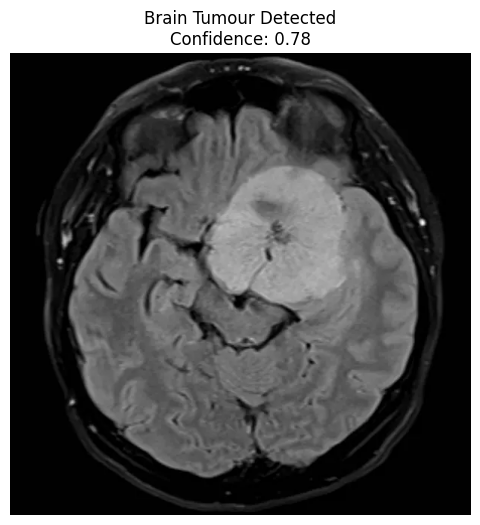


Prediction: yes


In [11]:
# ==========================
# Step 10: Upload Image
# ==========================
print("\nUpload an MRI image for prediction")

uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# ==========================
# Step 11: Read Image
# ==========================
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize image
img_resized = cv2.resize(
    img_rgb,
    (128,128)
)

# Normalize
img_normalized = img_resized / 255.0

# Add batch dimension
img_input = np.expand_dims(
    img_normalized,
    axis=0
)



# ==========================
# Step 12: Predict
# ==========================
prediction = model.predict(img_input)

predicted_class = (
    1 if prediction[0][0] > 0.5
    else 0
)

result = encoder.inverse_transform(
    [predicted_class]
)[0]

confidence = prediction[0][0]

# ==========================
# Step 13: Show Result
# ==========================
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis("off")

if predicted_class == 1:
    plt.title(
        f"Brain Tumour Detected\nConfidence: {confidence:.2f}"
    )
else:
    plt.title(
        f"No Brain Tumour Detected\nConfidence: {1-confidence:.2f}"
    )

plt.show()

print("\nPrediction:", result)